# Heterogeneous Ensemble

**Heterogeneous** means using **different types of models** in one
ensemble.

Example:

``` text
Logistic Regression + SVM + Decision Tree
```

Different models learn patterns differently, so combining them can
improve generalization.

------------------------------------------------------------------------

# Heterogeneous Boosting

**Heterogeneous boosting** means using different types of base models in
a boosting ensemble.

However, standard boosting algorithms such as **AdaBoost** and
**Gradient Boosting** generally use the **same type of base learner**
throughout the boosting process.

So remember:

``` text
Standard Boosting:
Model 1 → Model 2 → Model 3
(same type of base learner)

Heterogeneous Ensemble:
LR + SVM + DT
(different model types)
```

# Voting

**Voting** is an ensemble technique that combines predictions from
multiple ML models to make one final prediction.

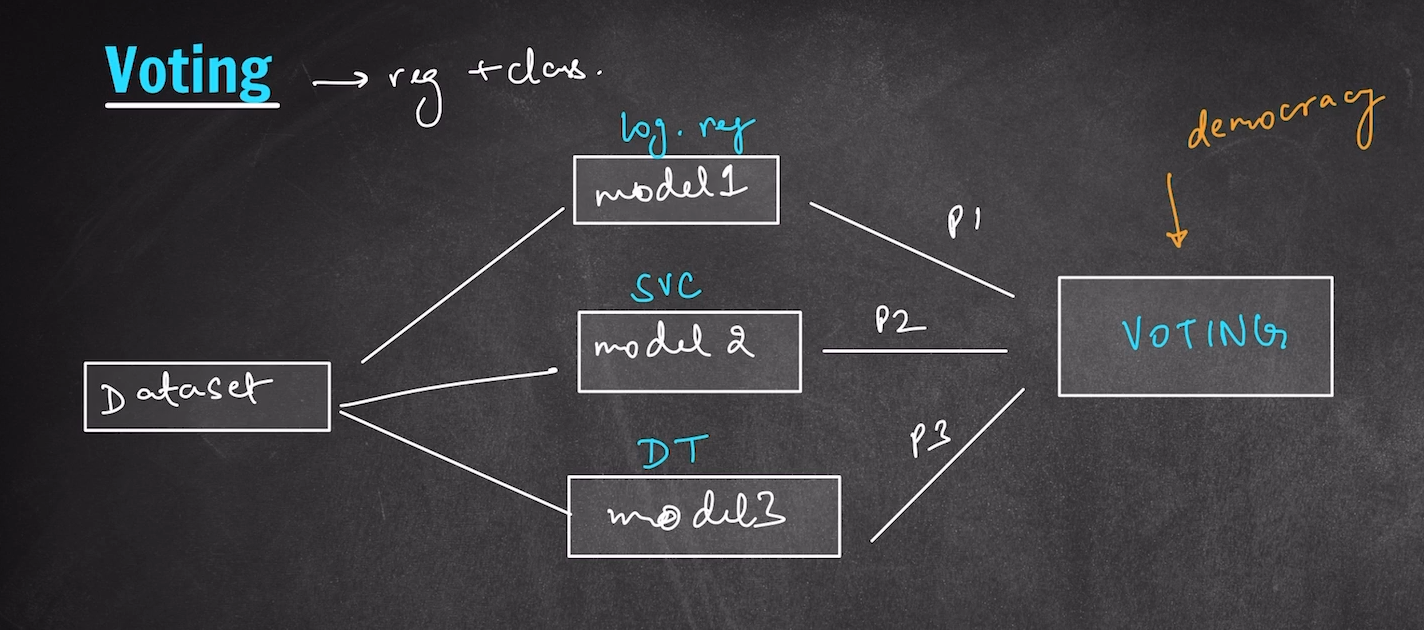

### Example

- Model 1 → Logistic Regression
- Model 2 → SVM
- Model 3 → Decision Tree

All models predict, and the **Voting Classifier** combines their
predictions.

### How Voting Works

``` text
Dataset
   |
   +--> Logistic Regression --+
   +--> SVM ------------------+--> Voting --> Final Prediction
   +--> Decision Tree --------+
```

### Hard Voting

The class with the **majority of votes** becomes the final prediction.

``` text
Model 1 → Class A
Model 2 → Class A
Model 3 → Class B

Final → Class A
```

**Hard Voting = Majority Vote**

### Soft Voting

Each model gives a **probability** for each class.

The probabilities are combined, and the class with the highest combined
probability is selected.

**Soft Voting = Combine Probabilities**

------------------------------------------------------------------------



### Heterogeneous Voting

Voting is commonly used with heterogeneous models:

``` text
Dataset
   |
   +--> Logistic Regression
   +--> SVM
   +--> Decision Tree
   |
   +--> Voting
          |
          +--> Final Prediction
```

**Different models → Different predictions → Combine predictions**




------------------------------------------------------------------------


| Concept                | Main Idea                                |
|------------------------|------------------------------------------|
| Voting                 | Combine predictions from multiple models |
| Hard Voting            | Majority class wins                      |
| Soft Voting            | Combine predicted probabilities          |
| Heterogeneous Ensemble | Uses different model types               |
| Boosting               | Models are trained sequentially          |
| Heterogeneous Voting   | Different model types vote together      |




# Classifier

In [2]:
from sklearn.ensemble import VotingClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


In [37]:
X, y= make_classification(
    n_samples=500,
    n_features=20,
    n_informative=5,
    n_redundant=2,
    random_state=42
    )

X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [34]:
lr=LogisticRegression()
svc=SVC()
dtc=DecisionTreeClassifier(max_depth=3)

In [8]:
voting_clf=VotingClassifier(
    estimators=[
        ("lr",lr),
        ("svc",svc),
        ("dtc",dtc)
    ])

In [9]:
voting_clf.fit(X_train,y_train)

,estimators,"[('lr', ...), ('svc', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [10]:
y_pred=voting_clf.predict(X_test)
print("Accuracy score: ", accuracy_score(y_test,y_pred))
print("Cr: ", classification_report(y_test,y_pred))

Accuracy score:  0.8333333333333334
Cr:                precision    recall  f1-score   support

           0       0.83      0.86      0.85        80
           1       0.84      0.80      0.82        70

    accuracy                           0.83       150
   macro avg       0.83      0.83      0.83       150
weighted avg       0.83      0.83      0.83       150



# Regressor

In [15]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

In [16]:
X, y= make_regression(
    n_samples=500,
    n_features=20,
    n_informative=5,
    random_state=42
    )

X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [18]:
lin_reg=LinearRegression()
dtr=DecisionTreeRegressor(max_depth=3)
svr=SVR()

In [23]:
from sklearn.ensemble import VotingRegressor
vr=VotingRegressor(
    estimators= [
        ("lin_reg",lin_reg),
        ("dtr",dtr),
        ("svr",svr)
    ])

In [24]:
vr.fit(X_train,y_train)

,estimators,"[('lin_reg', ...), ('dtr', ...), ...]"
,weights,None
,n_jobs,None
,verbose,False
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
,criterion,'squared_error'
,splitter,'best'


In [25]:
y_pred=vr.predict(X_test)

In [26]:
from sklearn.metrics import r2_score
print("R2 Score: ", r2_score(y_test,y_pred))

R2 Score:  0.8090433289971101


# Stacking

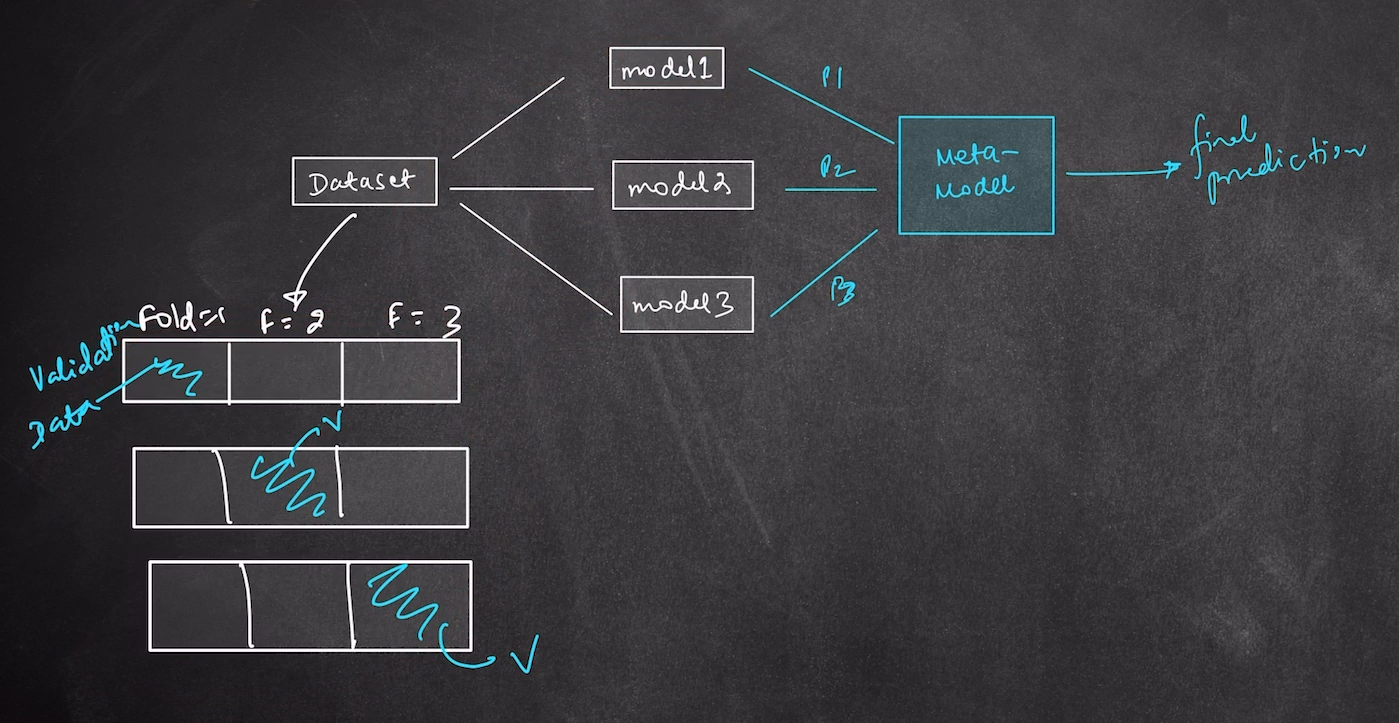

## What is Stacking?

**Stacking** is an ensemble learning technique where multiple **base
models** make predictions, and a **meta-model** learns how to combine
those predictions to make the final prediction.

``` text
                    Dataset
                       |
          ---------------------------
          |            |            |
       Model 1      Model 2      Model 3
          |            |            |
         P1           P2           P3
          \            |            /
           \           |           /
                 Meta-Model
                      |
               Final Prediction
```

## How Stacking Works

### 1. Train Base Models

Train multiple models on the dataset.

Example:

- Model 1 → Logistic Regression
- Model 2 → SVM
- Model 3 → Decision Tree

### 2. Get Predictions

Each base model produces a prediction:

``` text
Model 1 → P1
Model 2 → P2
Model 3 → P3
```

These predictions become the input to the meta-model.

### 3. Train the Meta-Model

The **meta-model** learns how to combine `P1`, `P2`, and `P3`.

``` text
P1 ──┐
P2 ──┼──→ Meta-Model → Final Prediction
P3 ──┘
```

The meta-model learns which predictions are more useful.

------------------------------------------------------------------------

## Preventing Overfitting

A major concern in stacking is **overfitting/data leakage**.

If base models predict on the same data they were trained on, their
predictions can be too optimistic.

### K-Fold Cross-Validation

We use **K-Fold Cross-Validation** to generate proper predictions for
the meta-model.

Example with `K = 3`:

``` text
Dataset
   |
   +--> Fold 1
   +--> Fold 2
   +--> Fold 3
```

For each fold:

1.  Train the base model on the other folds.
2.  Predict on the validation fold.
3.  Store those validation predictions.

After all folds, we get **out-of-fold predictions** for the complete
training dataset.

These predictions are then used to train the meta-model.

------------------------------------------------------------------------

## Why Use Stacking?

Different models may learn different patterns from the same dataset.

Stacking combines their predictions through a meta-model, which can
improve the final prediction.

``` text
Model 1 → Prediction
Model 2 → Prediction
Model 3 → Prediction
              |
              ↓
         Meta-Model
              |
              ↓
      Final Prediction
```

## Quick Revision

| Term                    | Meaning                                                      |
|-------------------------|--------------------------------------------------------------|
| Base Models             | Models that make the initial predictions                     |
| P1, P2, P3              | Predictions from the base models                             |
| Meta-Model              | Model that combines base-model predictions                   |
| K-Fold CV               | Used to generate validation predictions                      |
| Out-of-Fold Predictions | Predictions made on data not used to train that fold’s model |
| Final Prediction        | Prediction produced by the meta-model                        |

## One-Line Memory Trick

**Stacking = Base Models → Predictions → Meta-Model → Final Prediction**

**K-Fold CV = Helps create proper validation predictions and prevents
overfitting/data leakage.**


# Blending in Stacking

## Why Blending?

In **stacking**, we combine predictions from multiple base models using
a **meta-model**.

The problem is **overfitting**:

> If the meta-model is trained using predictions made on the same data
> that trained the base models, it may learn overly optimistic patterns.

**Blending** helps prevent this by keeping separate **training,
validation, and test sets**.

------------------------------------------------------------------------

## Dataset Split

The dataset is divided into three parts:

``` text
Dataset
   |
   +--> Train
   +--> Validation
   +--> Test
```

- **Train** → used to train the base models
- **Validation** → used to generate predictions for training the
  meta-model
- **Test** → used only for the final evaluation

------------------------------------------------------------------------

## How Blending Works in Stacking

Suppose we have three base models:

``` text
Model 1
Model 2
Model 3
```

### Step 1: Train Base Models

Each base model is trained using the **training set**.

``` text
Train
  |
  +--> Model 1
  +--> Model 2
  +--> Model 3
```

The validation and test sets are kept separate.

------------------------------------------------------------------------

### Step 2: Generate Validation Predictions

The trained base models predict on the **validation set**.

``` text
Validation Set
      |
      +--> Model 1 → val_pred1
      +--> Model 2 → val_pred2
      +--> Model 3 → val_pred3
```

Now we have:

``` text
val_pred1   val_pred2   val_pred3
     \          |          /
      \         |         /
          Validation
           Meta-Set
```

These validation predictions become the **input features for the
meta-model**.

------------------------------------------------------------------------

### Step 3: Train the Meta-Model

The meta-model is trained using:

``` text
[val_pred1, val_pred2, val_pred3]
```

as its input.

``` text
val_pred1 ──┐
val_pred2 ──┼──→ Meta-Model
val_pred3 ──┘
```

The meta-model learns how to combine the predictions of the base models.

------------------------------------------------------------------------

### Step 4: Generate Test Predictions

Now the base models predict on the **test set**.

``` text
Test Set
   |
   +--> Model 1 → test_pred1
   +--> Model 2 → test_pred2
   +--> Model 3 → test_pred3
```

These predictions form the **test meta-set**:

``` text
[test_pred1, test_pred2, test_pred3]
```

------------------------------------------------------------------------

### Step 5: Final Prediction

The trained meta-model receives the test meta-set and produces the final
prediction.

``` text
test_pred1 ──┐
test_pred2 ──┼──→ Meta-Model → Final Prediction
test_pred3 ──┘
```

------------------------------------------------------------------------

## Complete Flow

``` text
                    DATASET
                       |
          ---------------------------
          |            |            |
        Train       Validation      Test
          |            |            |
          ↓            ↓            ↓
      Base Models   Base Models   Base Models
          |            |            |
          |       val_pred1,2,3     |
          |            ↓            |
          |      Validation         |
          |       Meta-Set          |
          |            |             |
          |            ↓             |
          |       Meta-Model         |
          |            ↑             |
          |            |             |
          |      Test Meta-Set       |
          |   test_pred1,2,3         |
          |            |             |
          |            ↓             |
          |       Final Prediction   |
```

## Why Does This Prevent Overfitting?

The important point is:

**The meta-model does not train on predictions from the same data used
to train the base models.**

Instead:

``` text
Base Models
   ↓
trained on Train

Meta-Model
   ↓
trained on Validation Predictions
```

This gives the meta-model predictions on data that the base models did
**not** train on.

Therefore, the meta-model gets a more realistic view of the base models’
performance.

------------------------------------------------------------------------

## Blending vs K-Fold Stacking

### Blending

Uses a fixed validation set:

``` text
Train → Base Models
Validation → Meta-Model
Test → Final Evaluation
```

### K-Fold Stacking

Uses K-Fold Cross-Validation to create **out-of-fold predictions** for
the meta-model.

``` text
K-Fold CV
   ↓
Out-of-Fold Predictions
   ↓
Meta-Model
```

Both approaches aim to prevent the meta-model from learning from overly
optimistic predictions.

------------------------------------------------------------------------

## Quick Revision

| Part                | Purpose                                      |
|---------------------|----------------------------------------------|
| Train Set           | Train base models                            |
| Validation Set      | Generate predictions for meta-model training |
| Validation Meta-Set | `val_pred1, val_pred2, val_pred3`            |
| Meta-Model          | Learns how to combine base predictions       |
| Test Set            | Generate unseen base-model predictions       |
| Test Meta-Set       | `test_pred1, test_pred2, test_pred3`         |
| Final Prediction    | Produced by the meta-model                   |

## One-Line Memory Trick

**Blending = Train base models → predict on Validation → train
Meta-Model → predict on Test → Final Prediction.**


# Classifier

In [41]:
from sklearn.ensemble import StackingClassifier

In [42]:
X, y= make_classification(
    n_samples=500,
    n_features=20,
    n_informative=5,
    n_redundant=2,
    random_state=42
    )

X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [43]:
meta_model= LogisticRegression()

stacking_clf=StackingClassifier(
    estimators= [
        ("lr",lr),
        ("dtc",dtc),
        ("svc",svc)
    ],
    final_estimator=meta_model,
    cv=5
)

In [44]:
stacking_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('dtc', ...), ...]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [45]:
y_pred=stacking_clf.predict(X_test)

In [46]:
print("Accuracy score: ",accuracy_score(y_test,y_pred))

Accuracy score:  0.88


# Regressor

In [53]:
X, y= make_regression(
    n_samples=1500,
    n_features=30,
    n_informative=13,
    random_state=42
    )

X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [54]:
from sklearn.ensemble import StackingRegressor
sr=StackingRegressor(
    estimators= [
        ("lin_reg",lin_reg),
        ("dtr",dtr),
        ("svr",svr)
    ],
    cv=5
)

In [55]:
sr.fit(X_train,y_train)

,estimators,"[('lin_reg', ...), ('dtr', ...), ...]"
,final_estimator,None
,cv,5
,n_jobs,None
,passthrough,False
,verbose,0
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
y_pred=sr.predict(X_test)
y_pred_train= sr.predict(X_train)

print("training R2 score: ", r2_score(y_train,y_pred_train))
print("testing R2 score: ", r2_score(y_test,y_pred))

training R2 score:  0.9999999999999512
testing R2 score:  0.9999999999999527
